# Visualize two or more numerical variables
## Scatter plots
### Basic scatter plots

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

covid_totals = pd.read_csv("../05-data_cleaning/data/covidtotals.csv")


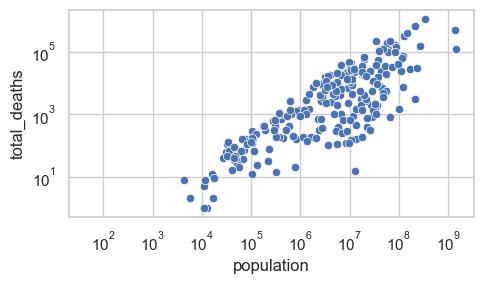

In [20]:
# let's inspect the relationship between population and total_deaths using a scatter plot

fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(5,3), tight_layout=True)
sns.set_theme(style="whitegrid")

sns.scatterplot(x=covid_totals['population'],
                y=covid_totals['total_deaths'],
                ax=ax)

plt.xscale('log')
plt.yscale('log')


### grouped scatter plot
We can group dots in different categories using colors

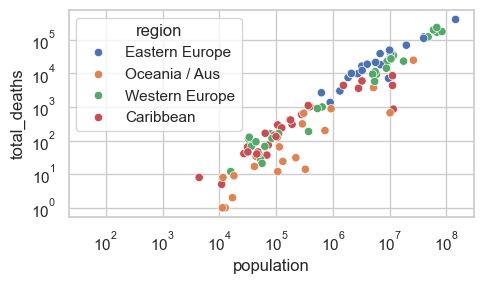

In [21]:
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(5,3), tight_layout=True)
sns.set_theme(style="whitegrid")

sns.scatterplot(data=covid_totals[covid_totals['region'].isin(['Western Europe', 'Caribbean', 'Oceania / Aus', 'Eastern Europe'])],
                x='population',
                y='total_deaths',
                hue='region',
                ax=ax)

plt.xscale('log')
plt.yscale('log')

We can also differentiate groups using different shapes of dots (or `style`).

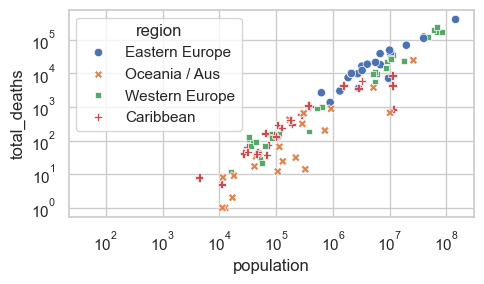

In [3]:
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(5,3), tight_layout=True)
sns.set_theme(style="whitegrid")

sns.scatterplot(data=covid_totals[covid_totals['region'].isin(['Western Europe', 'Caribbean', 'Oceania / Aus', 'Eastern Europe'])],
                x='population', y='total_deaths',
                hue='region',
                style='region', # specify which variable to distinguish using maerker style
                ax=ax)

plt.xscale('log')
plt.yscale('log')

### Regression plot
Usually we use sns.regplot

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

covid_totals = pd.read_csv("../05-data_cleaning/data/covidtotals.csv")
covid_totals['population_log'] = np.log1p(covid_totals['population']).fillna(0)
covid_totals['total_cases_log'] = np.log1p(covid_totals['total_cases']).fillna(0)

Text(0, 0.5, 'Total COVID Cases (log)')

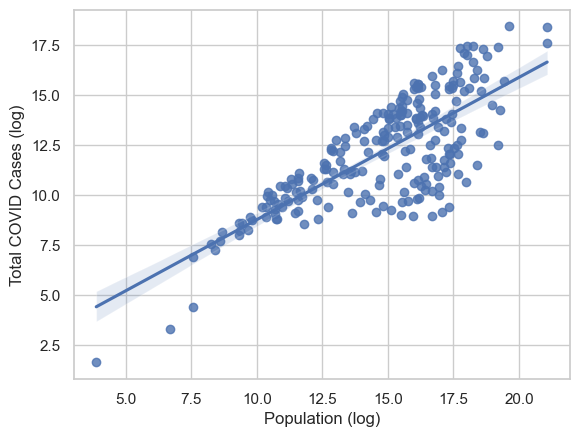

In [41]:
# Plot a simple regression plot

sns.regplot(data=covid_totals, x='population_log', y='total_cases_log')
sns.set_theme(style="whitegrid")

plt.xlabel("Population (log)")
plt.ylabel("Total COVID Cases (log)")


Text(56.120101562500025, 0.5, 'Total COVID cases (log)')

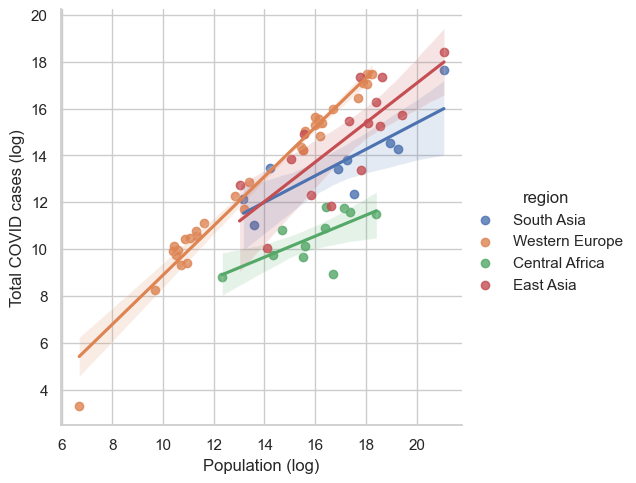

In [69]:
# Plot a grouped regression plot
sns.set_theme(style="whitegrid")

regions_to_plot = ['Western Europe', "Central Africa", "South Asia", "East Asia"]
sns.lmplot(data=covid_totals[covid_totals['region'].isin(regions_to_plot)], x='population_log', y='total_cases_log', hue='region')

plt.xlabel("Population (log)")
plt.ylabel("Total COVID cases (log)")

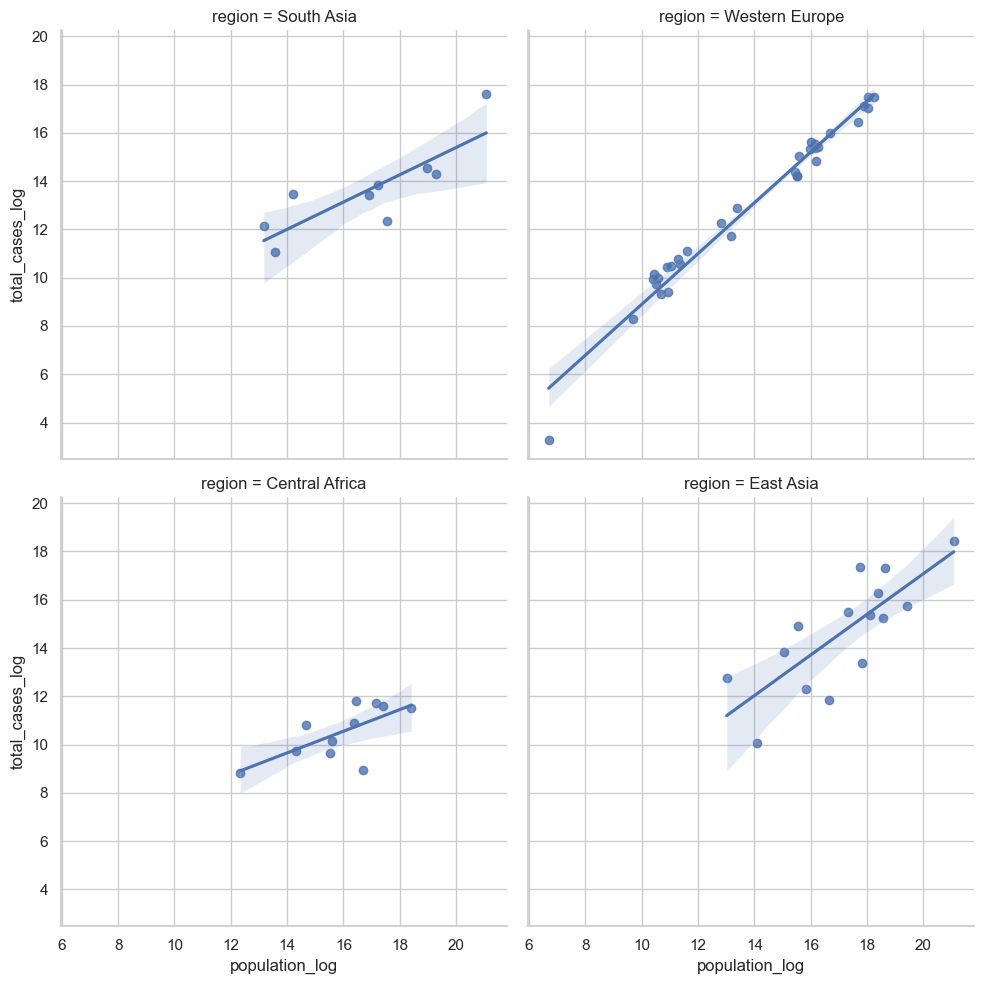

In [70]:
# or multiple panels

regions_to_plot = ['Western Europe', "Central Africa", "South Asia", "East Asia"]
g=sns.lmplot(data=covid_totals[covid_totals['region'].isin(regions_to_plot)], x='population_log', y='total_cases_log', col='region', col_wrap=2)


### Scatterplot with KDE

Example from seaborn official [website](https://seaborn.pydata.org/examples/layered_bivariate_plot.html)


<Axes: >

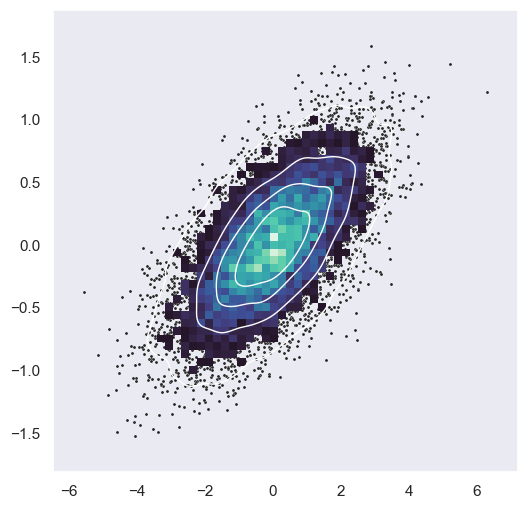

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="dark")

# Simulate data from a bivariate Gaussian
n = 10000
mean = [0, 0]
cov = [(2, .4), (.4, .2)]
rng = np.random.RandomState(0)
x, y = rng.multivariate_normal(mean, cov, n).T

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=50, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)

## Bubble chart
A bubble chart can be understand as a scatter plot with different sizes of dots.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

covid_totals = pd.read_csv("../05-data_cleaning/data/covidtotals.csv")

covid_totals.head()

,iso_code,lastdate,location,total_cases,total_deaths,total_cases_pm,total_deaths_pm,population,pop_density,median_age,gdp_per_capita,hosp_beds,vac_per_hund,aged_65_older,life_expectancy,hum_dev_ind,region
0,AFG,2024-02-04,Afghanistan,231539.0,7982.0,5629.611,194.073,41128772,54.422,18.6,1803.987,0.50,NaN,2.581,64.83,0.511,South Asia
1,ALB,2024-01-28,Albania,334863.0,3605.0,117813.348,1268.331,2842318,104.871,38.0,11803.431,2.89,NaN,13.188,78.57,0.795,Eastern Europe
2,DZA,2023-12-03,Algeria,272010.0,6881.0,6057.694,153.241,44903228,17.348,29.1,13913.839,1.90,NaN,6.211,76.88,0.748,North Africa
3,ASM,2023-09-17,American Samoa,8359.0,34.0,188712.044,767.581,44295,278.205,NaN,NaN,NaN,NaN,NaN,73.74,NaN,Oceania / Aus
4,AND,2023-05-07,Andorra,48015.0,159.0,601367.684,1991.408,79843,163.755,NaN,NaN,NaN,NaN,NaN,83.73,0.868,Western Europe


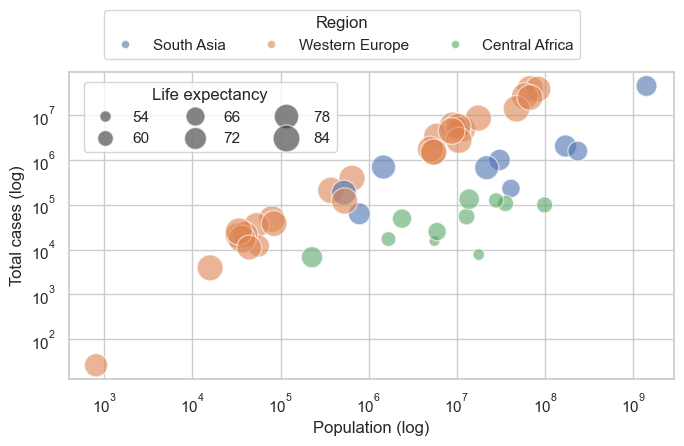

In [65]:
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(7,4), tight_layout=True)
sns.set_theme(style="whitegrid")

regions_to_plot = ['Western Europe', "Central Africa", "South Asia"]

sns.scatterplot(data=covid_totals[covid_totals['region'].isin(regions_to_plot)],
                x='population', y='total_cases',
                hue='region',
                size='life_expectancy',
                sizes=(60,400), alpha=.6,
                ax=ax)

handles, labels = ax.get_legend_handles_labels()
handles_hue, labels_hue=handles[1:len(regions_to_plot)+1], labels[1:len(regions_to_plot)+1]
handles_size, labels_size=handles[len(regions_to_plot)+2:], labels[len(regions_to_plot)+2:]
ax.get_legend().remove()

fig.legend(handles_hue, labels_hue, loc='upper center', ncols=len(regions_to_plot), mode=None,bbox_to_anchor=(.5,1.13),frameon=True, title="Region")
fig.legend(handles_size, labels_size, loc='upper left', ncols=3, mode=None,bbox_to_anchor=(.12,.95),frameon=True, title='Life expectancy')

plt.xlabel("Population (log)")
plt.ylabel("Total cases (log)")
plt.xscale('log')
plt.yscale('log')